<a href="https://colab.research.google.com/github/nikhilkanse2596/LOGISTIC-REGRESSION/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML CSV/bank-additional-full-1.csv",sep=';')

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000
mean,40.025111,258.315346,2.567890,962.465697,0.173033,0.081893,93.575749,-40.503113,3.621230,5167.029929
std,10.423948,259.302190,2.770286,186.934918,0.494975,1.570874,0.578862,4.628082,1.734463,72.257442
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
df.shape

(41199, 21)

In [ ]:
df.isnull().sum().sum()

np.int64(76)

In [ ]:
df.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(13)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

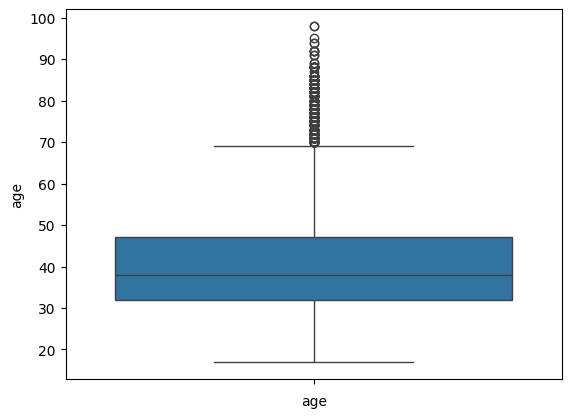

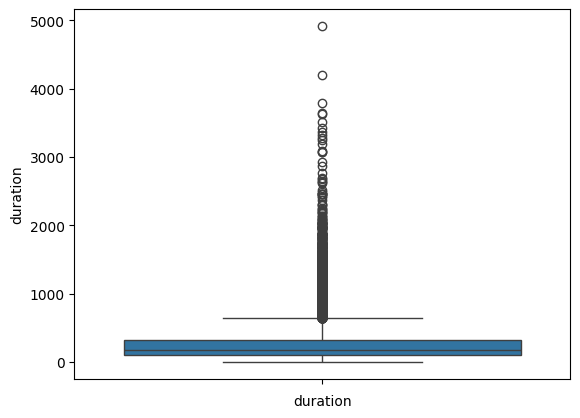

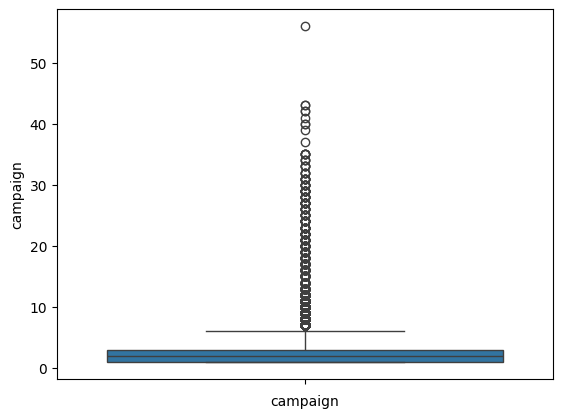

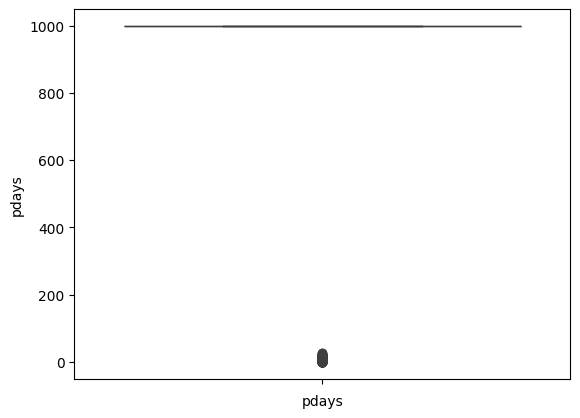

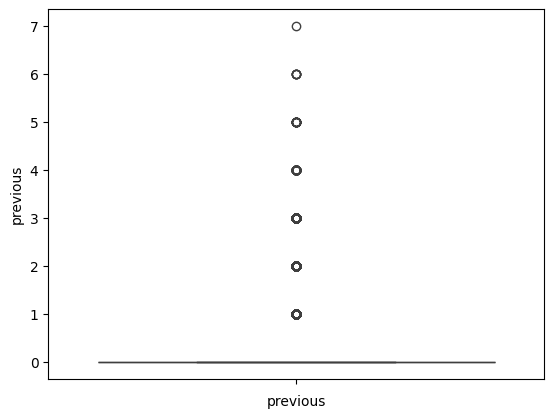

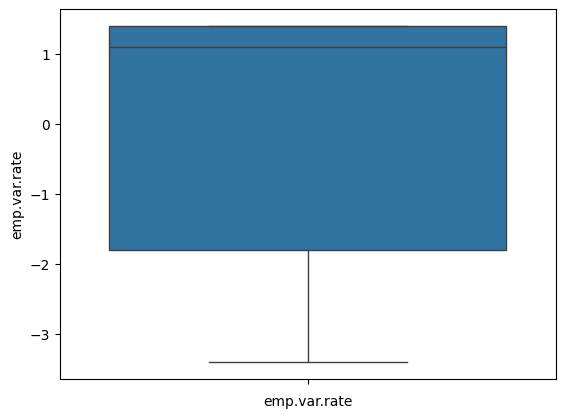

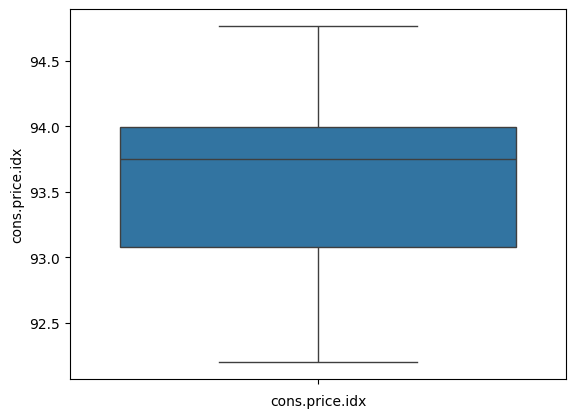

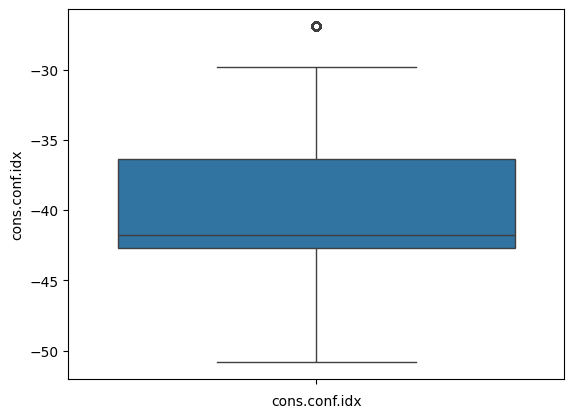

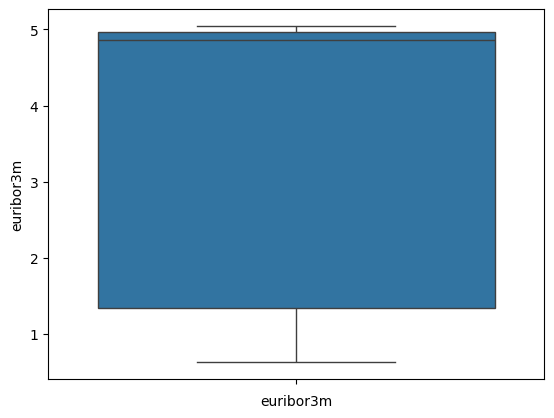

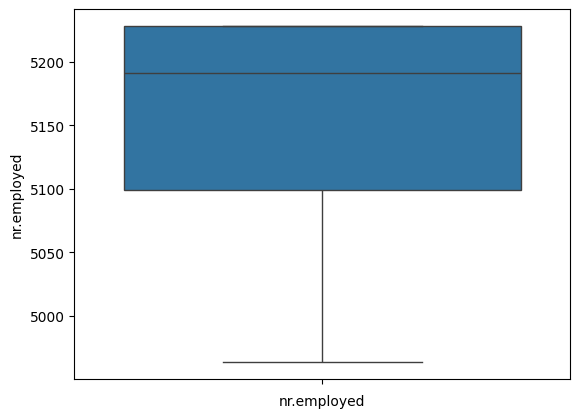

In [ ]:
for i in df.columns:
    if df[i].dtype != 'object':
        sns.boxplot(df[i])
        plt.xlabel(i)
        plt.show()


The columns in which we have outilers are:

1.Age

2.Duration

3.Campaign

4.pdays

5.previous


In [ ]:
outlier_col = ["duration", "campaign"]

In [ ]:
for i in outlier_col:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    UL=q3+1.5*IQR
    LL=q1-1.5*IQR
    df=df[(df[i]>=LL) & (df[i]<=UL)]

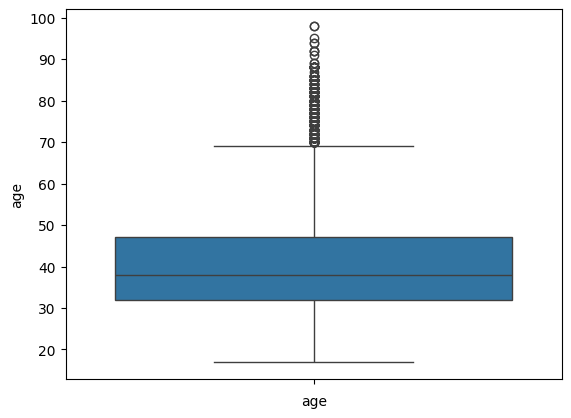

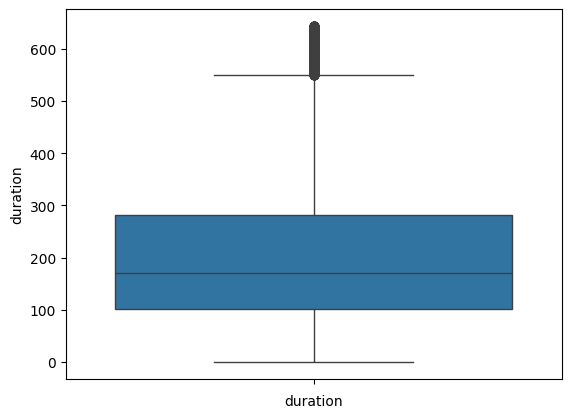

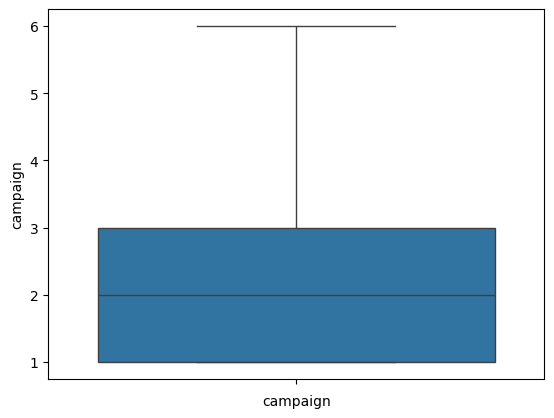

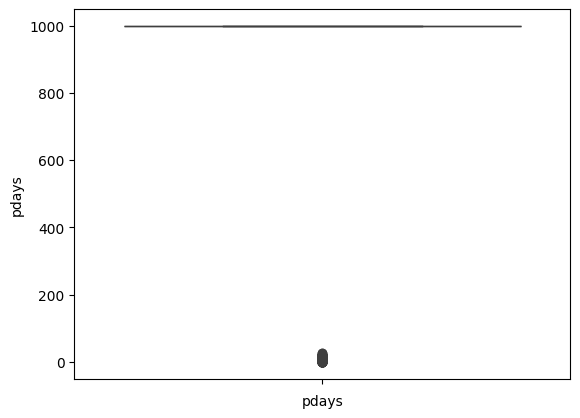

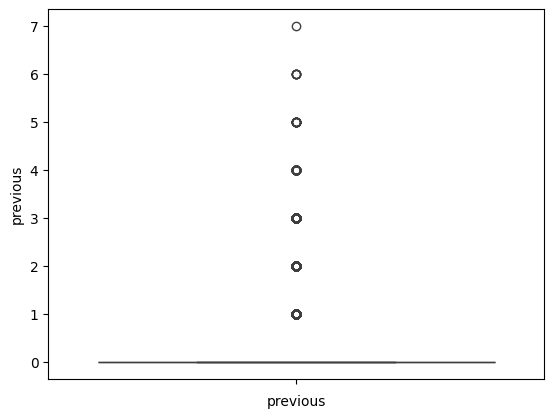

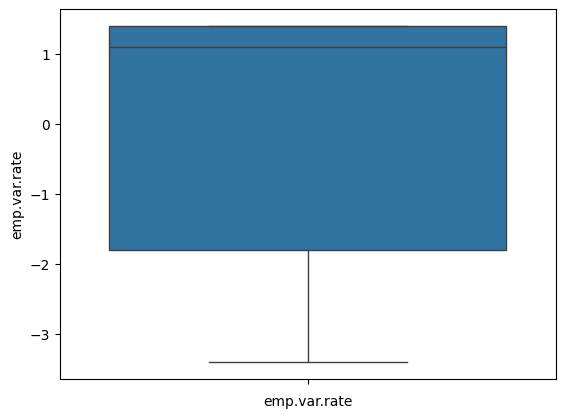

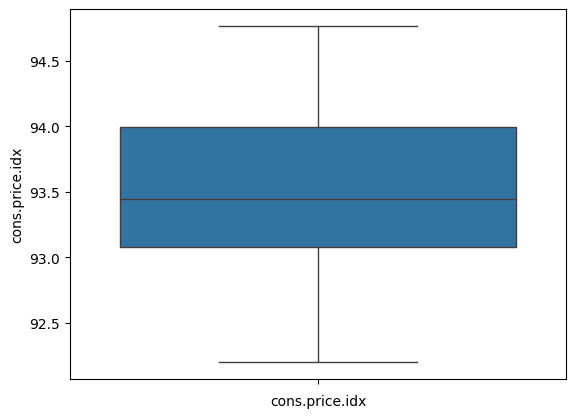

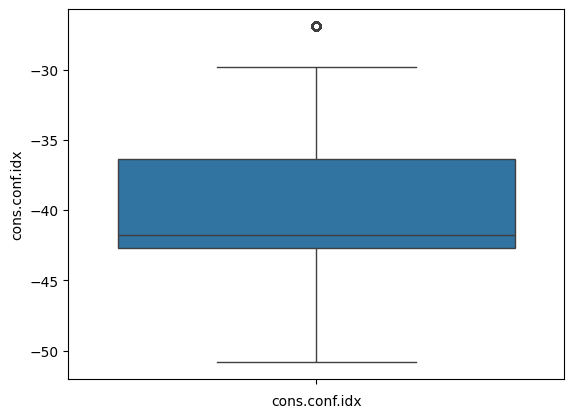

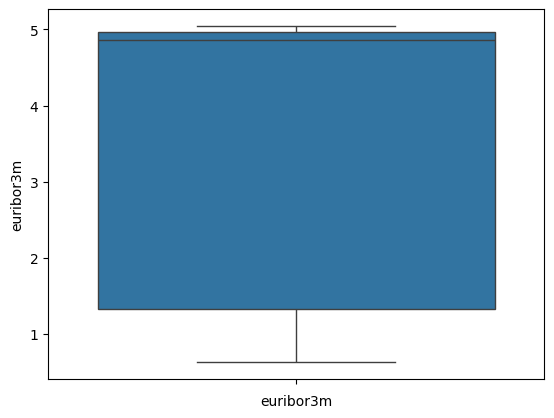

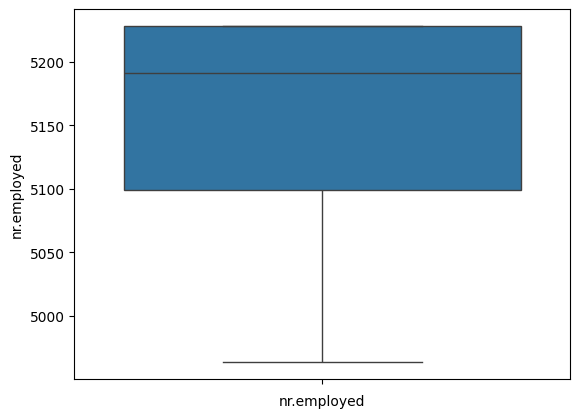

In [ ]:
for i in df.columns:
    if df[i].dtype != 'object':
        sns.boxplot(df[i])
        plt.xlabel(i)
        plt.show()


In [ ]:
df['y'] = np.where(df['y']=='yes',1,0)

In [ ]:
df['y'].unique()

array([0, 1])

In [ ]:
df['y'] = df['y'].astype(str)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35952 entries, 0 to 41193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35952 non-null  float64
 1   job             35952 non-null  object 
 2   marital         35952 non-null  object 
 3   education       35952 non-null  object 
 4   default         35952 non-null  object 
 5   housing         35952 non-null  object 
 6   loan            35952 non-null  object 
 7   contact         35952 non-null  object 
 8   month           35952 non-null  object 
 9   day_of_week     35952 non-null  object 
 10  duration        35952 non-null  float64
 11  campaign        35952 non-null  float64
 12  pdays           35952 non-null  float64
 13  previous        35952 non-null  float64
 14  poutcome        35952 non-null  object 
 15  emp.var.rate    35952 non-null  float64
 16  cons.price.idx  35952 non-null  float64
 17  cons.conf.idx   35952 non-null  floa

In [ ]:
col_list = list(df.columns)

# **LABEL ENCODING**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for i in col_list:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35952 entries, 0 to 41193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35952 non-null  float64
 1   job             35952 non-null  int64  
 2   marital         35952 non-null  int64  
 3   education       35952 non-null  int64  
 4   default         35952 non-null  int64  
 5   housing         35952 non-null  int64  
 6   loan            35952 non-null  int64  
 7   contact         35952 non-null  int64  
 8   month           35952 non-null  int64  
 9   day_of_week     35952 non-null  int64  
 10  duration        35952 non-null  float64
 11  campaign        35952 non-null  float64
 12  pdays           35952 non-null  float64
 13  previous        35952 non-null  float64
 14  poutcome        35952 non-null  int64  
 15  emp.var.rate    35952 non-null  float64
 16  cons.price.idx  35952 non-null  float64
 17  cons.conf.idx   35952 non-null  floa

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,1,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56.0,5,1,6,0,2,0,0,7,0,...,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44.0,9,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41187,74.0,5,1,5,0,2,0,0,7,0,...,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6,0


# **VIF CALCULATION**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
col_list = []
for i in df.columns:
    if df[i].dtype != 'object' and i != 'y':
        col_list.append(i)

X=df[col_list]
vif_data = pd.DataFrame()
vif_data["Features"] = X.columns
vif_data["VIF_score"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
print(vif_data)

          Features  VIF_score
0              age   1.254071
1              job   1.023570
2          marital   1.202608
3        education   1.099086
4          default   1.112209
5          housing   1.011575
6             loan   1.002765
7          contact   2.334778
8            month   1.813536
9      day_of_week   1.011989
10        duration   1.018178
11        campaign   1.025054
12           pdays   6.013566
13        previous   5.301231
14        poutcome   4.564616
15    emp.var.rate  42.776642
16  cons.price.idx   9.886092
17   cons.conf.idx   3.559411
18       euribor3m  94.796782
19     nr.employed  43.141603


In [ ]:
df=df.drop(['euribor3m'],axis=1)

In [ ]:
col_list = []
for i in df.columns:
    if df[i].dtype != 'object' and i != 'y':
        col_list.append(i)

X=df[col_list]
vif_data = pd.DataFrame()
vif_data["Features"] = X.columns
vif_data["VIF_score"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
print(vif_data)

          Features  VIF_score
0              age   1.251309
1              job   1.023343
2          marital   1.202570
3        education   1.096825
4          default   1.109760
5          housing   1.011152
6             loan   1.002706
7          contact   2.299780
8            month   1.224678
9      day_of_week   1.011856
10        duration   1.018159
11        campaign   1.019629
12           pdays   6.011391
13        previous   5.300401
14        poutcome   4.560519
15    emp.var.rate  28.570743
16  cons.price.idx   8.796904
17   cons.conf.idx   1.633336
18     nr.employed  14.711627


In [ ]:
df=df.drop(['emp.var.rate'],axis=1)

In [ ]:
col_list = []
for i in df.columns:
    if df[i].dtype != 'object' and i != 'y':
        col_list.append(i)

X=df[col_list]
vif_data = pd.DataFrame()
vif_data["Features"] = X.columns
vif_data["VIF_score"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
print(vif_data)

          Features  VIF_score
0              age   1.250108
1              job   1.023112
2          marital   1.202339
3        education   1.096568
4          default   1.107751
5          housing   1.010597
6             loan   1.002679
7          contact   2.016709
8            month   1.224677
9      day_of_week   1.011050
10        duration   1.018061
11        campaign   1.018278
12           pdays   5.978679
13        previous   5.281753
14        poutcome   4.541800
15  cons.price.idx   2.241518
16   cons.conf.idx   1.194850
17     nr.employed   1.997589


..

..

# **RFE - RECURSIVE FEATURE ELIMINATION**

In [ ]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.20, random_state=124)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_test

,y
36405,0
10276,0
30277,1
18153,0
18489,0
...,...
29265,1
33333,0
31640,0
18190,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.9311639549436797